# Scalable Diffusion Models with Transformer (DiT)

This notebook samples from pre-trained DiT models. DiTs are class-conditional latent diffusion models trained on ImageNet that use transformers in place of U-Nets as the DDPM backbone. DiT outperforms all prior diffusion models on the ImageNet benchmarks.

[Project Page](https://www.wpeebles.com/DiT) | [HuggingFace Space](https://huggingface.co/spaces/wpeebles/DiT) | [Paper](http://arxiv.org/abs/2212.09748) | [GitHub](github.com/facebookresearch/DiT)

# 1. Setup

We recommend using GPUs (Runtime > Change runtime type > Hardware accelerator > GPU). Run this cell to clone the DiT GitHub repo and setup PyTorch. You only have to run this once.

In [1]:
%cd ../

/home/sepuhopar/dev/SMILES-Project-27-Uncertainty-in-Diffusion


In [2]:
!git clone https://github.com/facebookresearch/DiT.git
import DiT, os
os.chdir('DiT')
#os.environ['PYTHONPATH'] = '/env/python:/content/DiT'
#!pip install diffusers timm --upgrade
# DiT imports:
import torch
from torchvision.utils import save_image
from diffusion import create_diffusion
from diffusers.models import AutoencoderKL
from download import find_model
from models import DiT_XL_2
from PIL import Image
from IPython.display import display
torch.set_grad_enabled(False)
device = "cuda" if torch.cuda.is_available() else "cpu"
if device == "cpu":
    print("GPU not found. Using CPU instead.")

fatal: destination path 'DiT' already exists and is not an empty directory.


Multiple distributions found for package optimum. Picked distribution: optimum
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


# Download DiT-XL/2 Models

You can choose between a 512x512 model and a 256x256 model. You can swap-out the LDM VAE, too.

In [3]:
image_size = 256 #@param [256, 512]
vae_model = "stabilityai/sd-vae-ft-ema" #@param ["stabilityai/sd-vae-ft-mse", "stabilityai/sd-vae-ft-ema"]
latent_size = int(image_size) // 8
# Load model:
model = DiT_XL_2(input_size=latent_size).to(device)
state_dict = find_model(f"DiT-XL-2-{image_size}x{image_size}.pt")
model.load_state_dict(state_dict)
model.eval() # important!
vae = AutoencoderKL.from_pretrained(vae_model).to(device)

/home/sepuhopar/miniconda3/envs/ldm/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


# 2. Sample from Pre-trained DiT Models

You can customize several sampling options. For the full list of ImageNet classes, [check out this](https://gist.github.com/yrevar/942d3a0ac09ec9e5eb3a).

In [ ]:
# Set user inputs:
seed = 0 #@param {type:"number"}
torch.manual_seed(seed)
num_sampling_steps = 250 #@param {type:"slider", min:0, max:1000, step:1}
cfg_scale = 4 #@param {type:"slider", min:1, max:10, step:0.1}
class_labels = 207, 360, 387, 974, 88, 979, 417, 279 #@param {type:"raw"}
samples_per_row = 4 #@param {type:"number"}

# Create diffusion object:
diffusion = create_diffusion(str(num_sampling_steps))

# Create sampling noise:
n = len(class_labels)
z = torch.randn(n, 4, latent_size, latent_size, device=device)
y = torch.tensor(class_labels, device=device)

# Setup classifier-free guidance:
z = torch.cat([z, z], 0)
y_null = torch.tensor([1000] * n, device=device)
y = torch.cat([y, y_null], 0)
model_kwargs = dict(y=y, cfg_scale=cfg_scale)

# Sample images:
samples = diffusion.p_sample_loop(
    model.forward_with_cfg, z.shape, z, clip_denoised=False, 
    model_kwargs=model_kwargs, progress=True, device=device
)
samples, _ = samples.chunk(2, dim=0)  # Remove null class samples
samples = vae.decode(samples / 0.18215).sample

# Save and display images:
save_image(samples, "sample.png", nrow=int(samples_per_row), 
           normalize=True, value_range=(-1, 1))
samples = Image.open("sample.png")
display(samples)

# 3. Ensemble Variance $U_{\text{ens}}(t, c)$

**Ensemble variance** measures how much the model’s clean-image prediction $\hat{x}_0$ disagrees across different random noise seeds at the same timestep $t$ and class $c$:

$$U_{\text{ens}}(t, c) = \mathrm{Var}_k\big[D_0(x_t^{(k)}, t, c)\big]$$

For each class $c$, we draw $K$ initial latents $z^{(1)}, \ldots, z^{(K)} \sim \mathcal{N}(0, I)$, run the **full** reverse diffusion path for each seed, record $\hat{x}_0 = D_0(x_t, t, c)$ at every spaced timestep, then compute **per-patch** variance across the $K$ runs (variance within each DiT patch, averaged over channels and patch pixels).

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Ensemble variance settings
K = 16  #@param {type:"integer"}
ens_cfg_scale = 4.0  #@param {type:"slider", min:1, max:10, step:0.1}
ens_num_sampling_steps = 250  #@param {type:"slider", min:10, max:1000, step:1}
ens_class_labels = (207, 414, 360, 387, 974, 88, 979, 417, 279, )  #@param {type:"raw"}  # one or more ImageNet class ids
ens_seed_base = 0  #@param {type:"integer"}
patch_size = 2  # DiT-XL/2 latent patch size

ens_diffusion = create_diffusion(str(ens_num_sampling_steps))
shape = (1, 4, latent_size, latent_size)


def x0_to_patch_variance(x0_ensemble, patch_size=2):
    """Per-patch variance of K x0 predictions: (K,C,H,W) -> (H//p, W//p)."""
    var_map = x0_ensemble.var(dim=0)  # (C, H, W)
    c, h, w = var_map.shape
    var_map = var_map.reshape(
        c, h // patch_size, patch_size, w // patch_size, patch_size
    )
    return var_map.mean(dim=(0, 2, 4))


def run_ensemble_x0_for_class(class_label, K=16, seed_base=0, progress=True):
    """Run K full-path samples for one class; return x0 preds and original timestep bins."""
    x0_by_t = []
    timestep_bins = [
        ens_diffusion.timestep_map[i]
        for i in range(ens_diffusion.num_timesteps - 1, -1, -1)
    ]

    iterator = range(K)
    if progress:
        iterator = tqdm(iterator, desc=f"class {class_label}", leave=False)

    for k in iterator:
        torch.manual_seed(seed_base + k)
        z = torch.randn(*shape, device=device)
        z_cfg = torch.cat([z, z], dim=0)
        y = torch.tensor([class_label, 1000], device=device)
        model_kwargs = dict(y=y, cfg_scale=ens_cfg_scale)

        traj = []
        for out in ens_diffusion.p_sample_loop_progressive(
            model.forward_with_cfg,
            z_cfg.shape,
            z_cfg,
            clip_denoised=False,
            model_kwargs=model_kwargs,
            device=device,
            progress=False,
        ):
            traj.append(out["pred_xstart"][:1].cpu())
        #print(traj[0].shape)
        x0_by_t.append(torch.stack(traj, dim=0))  # (T, 1, C, H, W)

    # (K, T, C, H, W)
    x0_ensemble = torch.stack([x.squeeze(1) for x in x0_by_t], dim=0)
    return x0_ensemble, timestep_bins


# U_ens[c][t]: per-patch variance map; also store scalar mean per (c, t)
U_ens_patch = {}
U_ens_mean = {}

for class_label in ens_class_labels:
    x0_ensemble, timestep_bins = run_ensemble_x0_for_class(
        class_label, K=K, seed_base=ens_seed_base, progress=True
    )
    num_t = x0_ensemble.shape[1]
    patch_maps = torch.stack(
        [x0_to_patch_variance(x0_ensemble[:, t], patch_size) for t in range(num_t)],
        dim=0,
    )  # (T, ph, pw)
    U_ens_patch[class_label] = patch_maps.numpy()
    U_ens_mean[class_label] = {
        int(timestep_bins[t]): float(patch_maps[t].mean()) for t in range(num_t)
    }
    print(
        f"class {class_label}: {num_t} timestep bins, "
        f"patch grid {patch_maps.shape[-2]}x{patch_maps.shape[-1]}, "
        f"mean U_ens range [{patch_maps.mean(dim=(1, 2)).min():.4f}, "
        f"{patch_maps.mean(dim=(1, 2)).max():.4f}]"
    )



class 207:   0%|          | 0/16 [00:00<?, ?it/s]

class 207: 250 timestep bins, patch grid 16x16, mean U_ens range [0.0247, 0.7211]


class 414:   0%|          | 0/16 [00:00<?, ?it/s]

class 414: 250 timestep bins, patch grid 16x16, mean U_ens range [0.0802, 0.5574]


class 360:   0%|          | 0/16 [00:00<?, ?it/s]

...

class 979: 250 timestep bins, patch grid 16x16, mean U_ens range [0.0661, 0.5132]


class 417:   0%|          | 0/16 [00:00<?, ?it/s]

class 417: 250 timestep bins, patch grid 16x16, mean U_ens range [0.0683, 0.8107]


class 279:   0%|          | 0/16 [00:00<?, ?it/s]

class 279: 250 timestep bins, patch grid 16x16, mean U_ens range [0.0475, 0.7697]


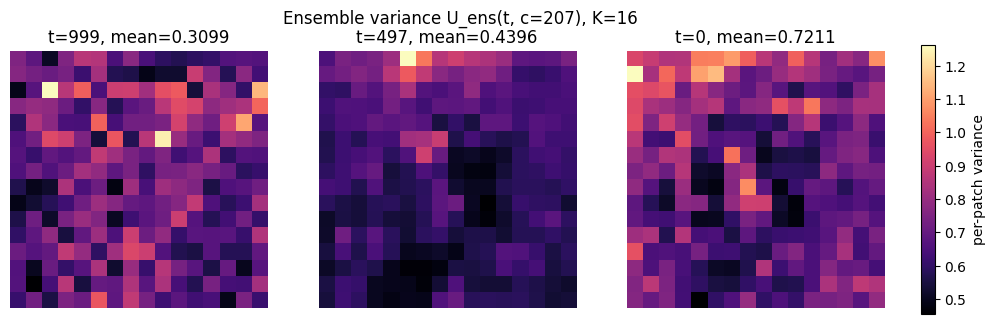

In [5]:
# Visualize per-patch U_ens at early / mid / late timesteps for the first class
vis_class = ens_class_labels[0]
maps = U_ens_patch[vis_class]
t_show = [0, len(maps) // 2, len(maps) - 1]
t_labels = list(U_ens_mean[vis_class].keys())
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, ti in zip(axes, t_show):
    im = ax.imshow(maps[ti], cmap="magma")
    ax.set_title(f"t={t_labels[ti]}, mean={maps[ti].mean():.4f}")
    ax.axis("off")
fig.colorbar(im, ax=axes, fraction=0.02, pad=0.04, label="per-patch variance")
fig.suptitle(f"Ensemble variance U_ens(t, c={vis_class}), K={K}")
#plt.tight_layout()
plt.show()

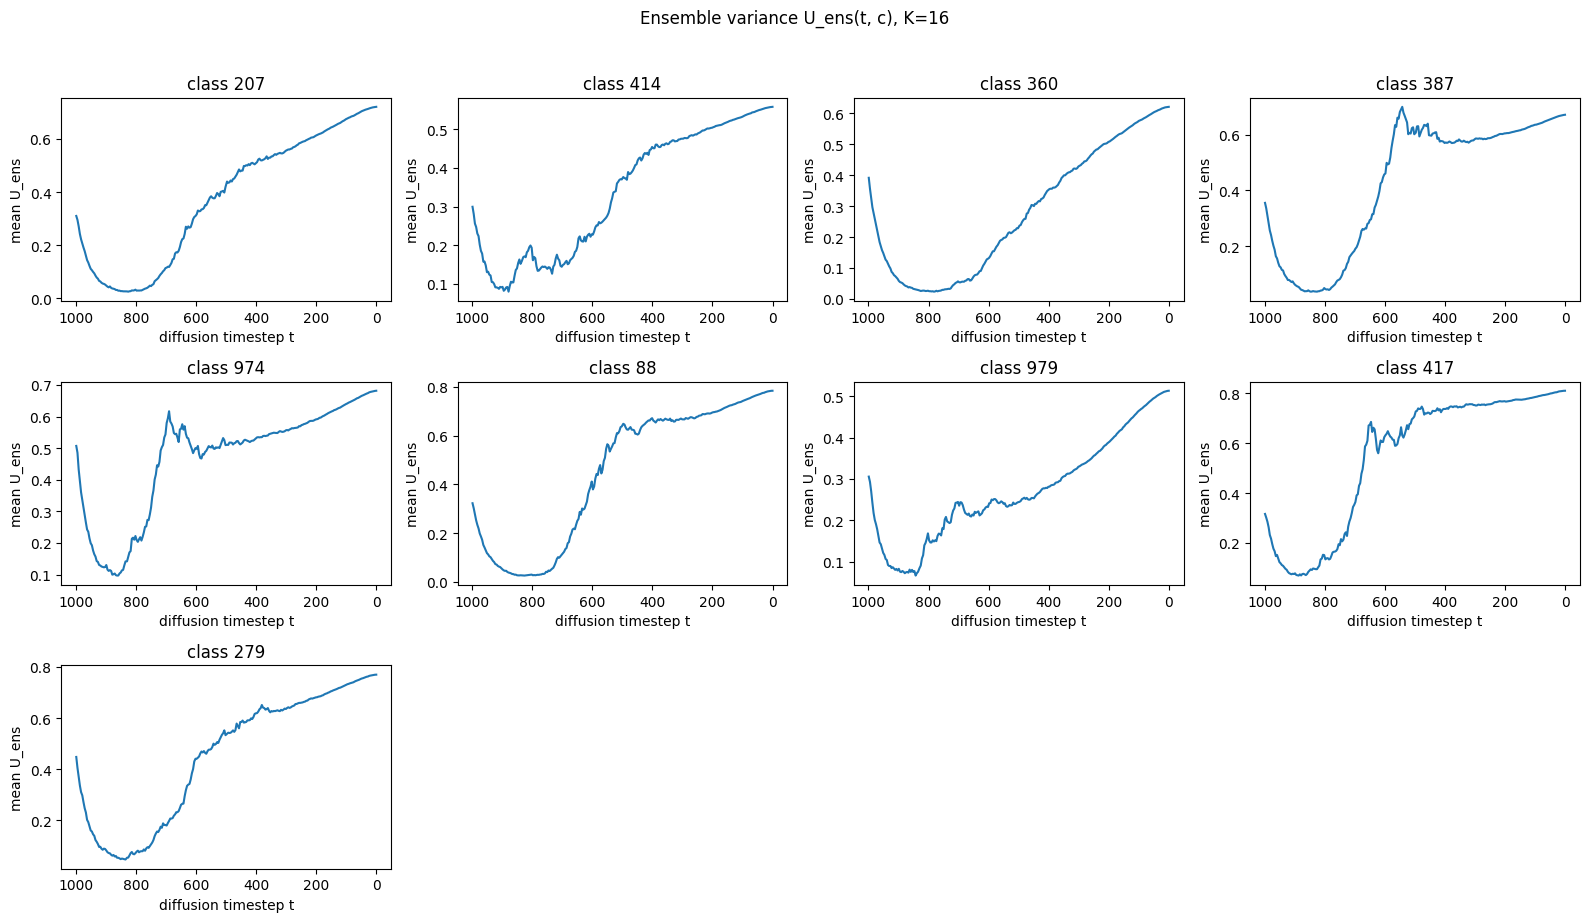

In [22]:
# Per-class U_ens(t) profiles for all classes in U_ens_mean
classes = list(U_ens_mean.keys())
n_classes = len(classes)
ncols = min(4, n_classes)
nrows = int(np.ceil(n_classes / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), squeeze=False)

for ax, class_label in zip(axes.flat, classes):
    ts = list(U_ens_mean[class_label].keys())
    vals = list(U_ens_mean[class_label].values())
    ax.plot(ts, vals)
    ax.invert_xaxis()  # 999 -> 0 left to right as denoising progresses
    ax.set_title(f"class {class_label}")
    ax.set_xlabel("diffusion timestep t")
    ax.set_ylabel("mean U_ens")

# hide unused subplots
for ax in axes.flat[n_classes:]:
    ax.axis("off")

fig.suptitle(f"Ensemble variance U_ens(t, c), K={K}", y=1.02)
plt.tight_layout()
plt.show()

# 4. Attention Entropy $U_{\text{attn}}(t, \ell)$

**Attention entropy** measures how spread out each DiT block's self-attention distribution is at timestep $t$:

$$U_{\text{attn}}(t, \ell) = -\frac{1}{HN}\sum_{h=1}^{H}\sum_{i=1}^{N}\sum_{j=1}^{N} A^{(\ell)}_{h,ij}\log A^{(\ell)}_{h,ij}$$

For each class $c$, we run **one** reverse-diffusion path (single seed), hook into every attention block $\ell$, extract softmax attention maps $A^{(\ell)}$, compute Shannon entropy per head and query patch, then average across heads and patches.

In [ ]:
# Task 1.3 — Attention entropy U_attn(t, ℓ)
from tqdm.auto import tqdm

# Settings (reuse ensemble classes/steps if already defined above)
attn_class_labels = ens_class_labels  # or set explicitly, e.g. (207, 360)
attn_num_sampling_steps = ens_num_sampling_steps if "ens_num_sampling_steps" in globals() else 250
attn_seed = ens_seed_base if "ens_seed_base" in globals() else 0
attn_use_cfg = False  # single conditional pass (Task 1.3)

attn_diffusion = create_diffusion(str(attn_num_sampling_steps))
attn_shape = (1, 4, latent_size, latent_size)
num_blocks = len(model.blocks)

timestep_bins_attn = [
    attn_diffusion.timestep_map[i]
    for i in range(attn_diffusion.num_timesteps - 1, -1, -1)
]


def _modulate(x, shift, scale):
    return x * (1 + scale.unsqueeze(1)) + shift.unsqueeze(1)


def _attn_weights_and_output(attn_module, x):
    """Extract softmax attention weights and block output from a timm Attention layer."""
    b, n, _ = x.shape
    qkv = attn_module.qkv(x).reshape(
        b, n, 3, attn_module.num_heads, attn_module.head_dim
    ).permute(2, 0, 3, 1, 4)
    q, k, v = qkv.unbind(0)
    q, k = attn_module.q_norm(q), attn_module.k_norm(k)
    scale = getattr(attn_module, "scale", attn_module.head_dim ** -0.5)
    q = q * scale
    weights = (q @ k.transpose(-2, -1)).softmax(dim=-1)  # (B, H, N, N)
    out = (weights @ v).transpose(1, 2).reshape(b, n, attn_module.attn_dim)
    out = attn_module.norm(out)
    out = attn_module.proj(out)
    return weights, out


def _attention_entropy(weights, eps=1e-8):
    """Mean Shannon entropy over heads and query patches."""
    row_entropy = -(weights * torch.log(weights + eps)).sum(dim=-1)  # (B, H, N)
    return row_entropy.mean()


@torch.no_grad()
def forward_dit_attn_entropy(dit_model, x, t, y):
    """Run one conditional DiT forward pass and return per-block attention entropy."""
    x = dit_model.x_embedder(x) + dit_model.pos_embed
    c = dit_model.t_embedder(t) + dit_model.y_embedder(y, train=False)
    entropies = []
    for block in dit_model.blocks:
        shift_msa, scale_msa, gate_msa, shift_mlp, scale_mlp, gate_mlp = (
            block.adaLN_modulation(c).chunk(6, dim=1)
        )
        x_norm = _modulate(block.norm1(x), shift_msa, scale_msa)
        weights, attn_out = _attn_weights_and_output(block.attn, x_norm)
        entropies.append(_attention_entropy(weights))
        x = x + gate_msa.unsqueeze(1) * attn_out
        x = x + gate_mlp.unsqueeze(1) * block.mlp(
            _modulate(block.norm2(x), shift_mlp, scale_mlp)
        )
    return entropies


def run_attention_entropy_for_class(class_label, seed=0, use_cfg=False, progress=True):
    """Single-path sampling; record U_attn(t, ℓ) for every timestep bin and block."""
    torch.manual_seed(seed)
    z = torch.randn(*attn_shape, device=device)
    y = torch.tensor([class_label], device=device)

    if use_cfg:
        z_in = torch.cat([z, z], dim=0)
        y_in = torch.tensor([class_label, 1000], device=device)
        model_fn = model.forward_with_cfg
        model_kwargs = dict(y=y_in, cfg_scale=ens_cfg_scale)
        img = z_in
    else:
        model_fn = model.forward
        model_kwargs = dict(y=y)
        img = z

    block_entropies = [[] for _ in range(num_blocks)]

    respaced_indices = list(range(attn_diffusion.num_timesteps))[::-1]
    iterator = respaced_indices
    if progress:
        iterator = tqdm(iterator, desc=f"attn class {class_label}", leave=False)

    for respaced_t in iterator:
        orig_t = int(attn_diffusion.timestep_map[respaced_t])
        t_orig = torch.tensor([orig_t], device=device)

        if use_cfg:
            # Use conditional half only for attention entropy.
            ent_list = forward_dit_attn_entropy(model, img[:1], t_orig, y)
        else:
            ent_list = forward_dit_attn_entropy(model, img, t_orig, y)

        for block_idx, ent in enumerate(ent_list):
            block_entropies[block_idx].append(float(ent))

        t_batch = torch.full((img.shape[0],), respaced_t, device=device, dtype=torch.long)
        out = attn_diffusion.p_sample(
            model_fn,
            img,
            t_batch,
            clip_denoised=False,
            model_kwargs=model_kwargs,
        )
        img = out["sample"]

    entropy_by_block = np.array(block_entropies, dtype=np.float32)  # (num_blocks, T)
    return entropy_by_block, timestep_bins_attn


# U_attn[class][block] -> {sampling_step: entropy}
# sampling_step on [0, attn_num_sampling_steps]: 0 = first reverse step, 250 = final
U_attn = {}
U_attn_mean_over_blocks = {}

for class_label in attn_class_labels:
    entropy_by_block, bins = run_attention_entropy_for_class(
        class_label, seed=attn_seed, use_cfg=attn_use_cfg, progress=True
    )
    num_steps = len(bins)
    # Map recorded bins onto [0, attn_num_sampling_steps] (0=first, 250=final)
    step_axis = np.linspace(0, attn_num_sampling_steps, num_steps)
    U_attn[class_label] = {
        block_idx: {
            float(step_axis[i]): float(entropy_by_block[block_idx, i]) for i in range(num_steps)
        }
        for block_idx in range(num_blocks)
    }
    mean_over_blocks = entropy_by_block.mean(axis=0)
    U_attn_mean_over_blocks[class_label] = {
        float(step_axis[i]): float(mean_over_blocks[i]) for i in range(num_steps)
    }
    print(
        f"class {class_label}: {num_steps} steps on [0, {attn_num_sampling_steps}] "
        f"(0=first → {attn_num_sampling_steps}=final), {num_blocks} blocks, "
        f"mean U_attn range [{mean_over_blocks.min():.4f}, {mean_over_blocks.max():.4f}]"
    )

# Mean attention entropy across blocks, per class
classes = list(U_attn_mean_over_blocks.keys())
n_classes = len(classes)
ncols = min(4, n_classes)
nrows = int(np.ceil(n_classes / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), squeeze=False)

for ax, class_label in zip(axes.flat, classes):
    steps = list(U_attn_mean_over_blocks[class_label].keys())
    vals = list(U_attn_mean_over_blocks[class_label].values())
    ax.plot(steps, vals, color="tab:green")
    ax.set_xlim(0, attn_num_sampling_steps)
    ax.set_title(f"class {class_label}")
    ax.set_xlabel(f"sampling step (0=first → {attn_num_sampling_steps}=final)")
    ax.set_ylabel("mean U_attn (all blocks)")

for ax in axes.flat[n_classes:]:
    ax.axis("off")

fig.suptitle("Attention entropy U_attn(step), averaged over DiT blocks", y=1.02)
plt.tight_layout()
plt.show()

# Early / mid / late blocks for the first class
vis_class = classes[0]
layer_show = [0, num_blocks // 2, num_blocks - 1]
layer_names = ["early", "mid", "late"]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)
for ax, block_idx, name in zip(axes, layer_show, layer_names):
    steps = list(U_attn[vis_class][block_idx].keys())
    vals = list(U_attn[vis_class][block_idx].values())
    ax.plot(steps, vals, color="tab:purple")
    ax.set_xlim(0, attn_num_sampling_steps)
    ax.set_title(f"block {block_idx} ({name})")
    ax.set_xlabel(f"sampling step (0=first → {attn_num_sampling_steps}=final)")
axes[0].set_ylabel("U_attn")
fig.suptitle(f"Per-block attention entropy, class {vis_class}")
plt.tight_layout()
plt.show()


# 5. Ensemble Variance with Fixed Per-Step Noise

During reverse diffusion, each step (except the last) samples
$$x_{t-1} = \mu_\theta(x_t,t) + \sigma_t\,\varepsilon,\qquad \varepsilon\sim\mathcal{N}(0,I).$$

In the standard ensemble (#3), both the **initial latent** $z$ and these **per-step** $\varepsilon$ differ across seeds.

Here we isolate initial-seed diversity: for each of $K=16$ runs we draw a different $z^{(k)}$, but **reuse the same hardcoded per-step noise** $\varepsilon_t$ at every sampling step (seeded once). Then we plot $U_{\text{ens}}$ as before and show the **final decoded images** for all 16 runs.

fixed-noise class 207:   0%|          | 0/16 [00:00<?, ?it/s]

[fixed noise] class 207: 250 steps on [0, 250], K=16, mid_step=126, mean U_ens range [0.0009, 0.3099]


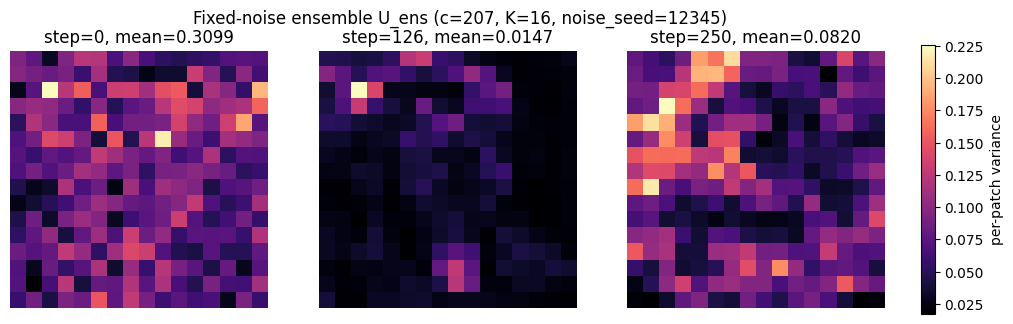

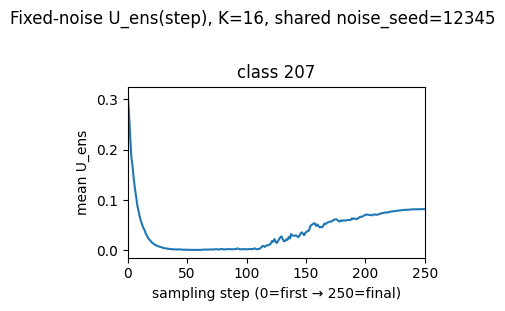

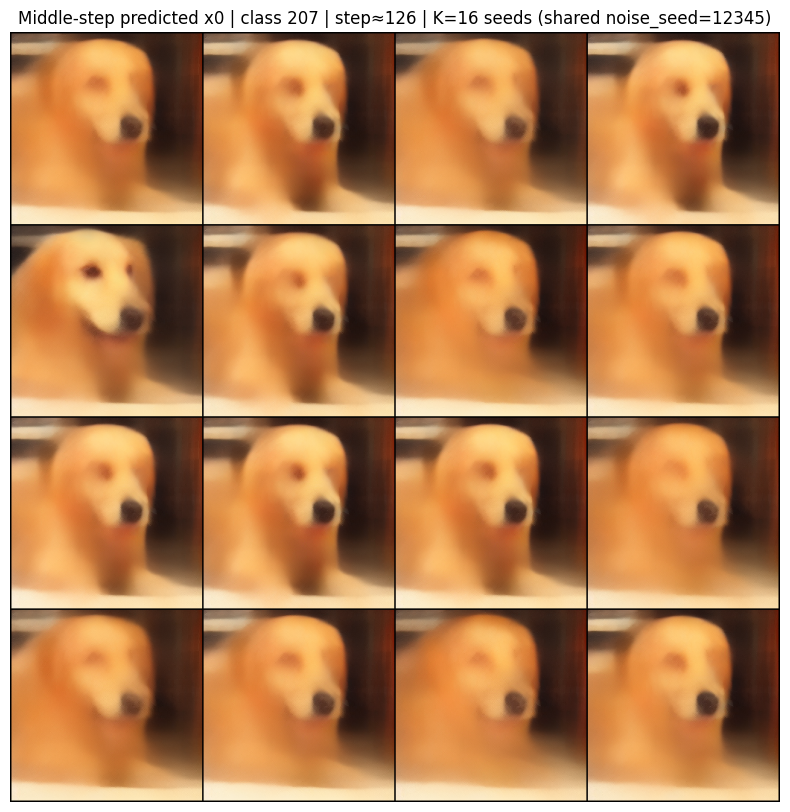

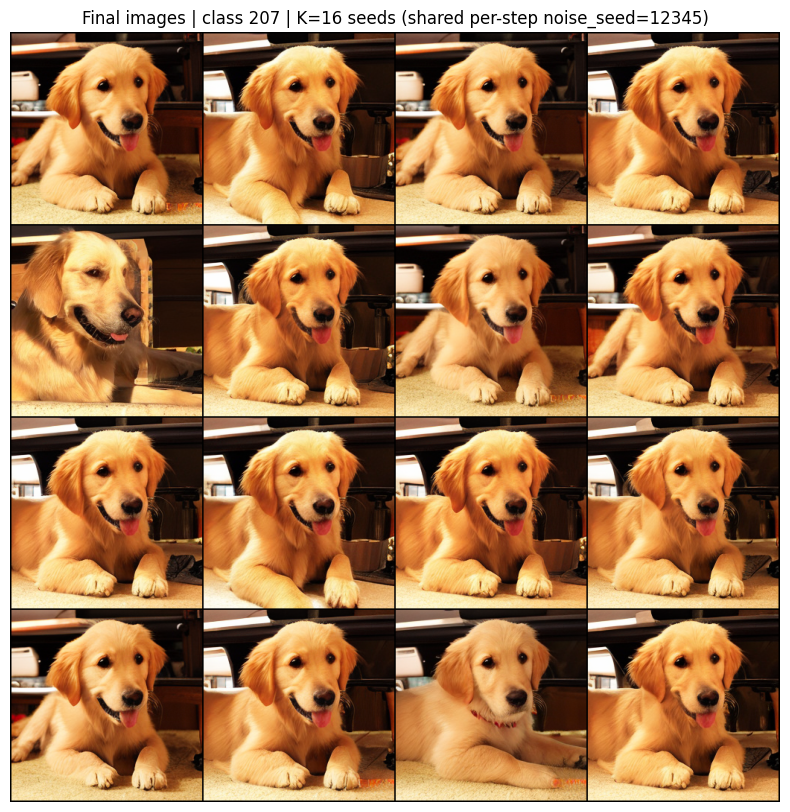

In [5]:
# Task: U_ens with fixed per-step transition noise + final images for K seeds
from torchvision.utils import make_grid
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import numpy as np


# Settings (reuse ensemble knobs when available)
fix_K = K if "K" in globals() else 16
fix_cfg_scale = ens_cfg_scale if "ens_cfg_scale" in globals() else 4.0
fix_num_sampling_steps = ens_num_sampling_steps if "ens_num_sampling_steps" in globals() else 250
# Same classes as standard ensemble (override if you want a subset)
fix_class_labels = ens_class_labels if "ens_class_labels" in globals() else (207,)
fix_seed_base = ens_seed_base if "ens_seed_base" in globals() else 0
fix_noise_seed = 12345  # hardcoded seed for shared per-step noise
fix_patch_size = patch_size if "patch_size" in globals() else 2

fix_diffusion = create_diffusion(str(fix_num_sampling_steps))
fix_shape = (1, 4, latent_size, latent_size)
# Sampling-step axis: 0 = first reverse step, fill_num_sampling_steps = final
fix_step_axis = np.linspace(0, fix_num_sampling_steps, fix_diffusion.num_timesteps)


def _p_sample_with_noise(diffusion, model, x, t, step_noise, clip_denoised=False, model_kwargs=None):
    """Like diffusion.p_sample, but uses provided step_noise instead of randn."""
    out = diffusion.p_mean_variance(
        model, x, t, clip_denoised=clip_denoised, model_kwargs=model_kwargs
    )
    nonzero_mask = (t != 0).float().view(-1, *([1] * (len(x.shape) - 1)))
    sample = out["mean"] + nonzero_mask * torch.exp(0.5 * out["log_variance"]) * step_noise
    return {"sample": sample, "pred_xstart": out["pred_xstart"]}


def precompute_shared_step_noise(diffusion, shape_cfg, noise_seed, device):
    """One ε tensor per reverse step, shared across all ensemble members."""
    g = torch.Generator(device=device)
    g.manual_seed(noise_seed)
    noises = []
    for _ in range(diffusion.num_timesteps):
        noises.append(torch.randn(*shape_cfg, generator=g, device=device))
    return noises  # length T; index 0 used at first reverse step (highest t)


def run_ensemble_fixed_noise_for_class(
    class_label, K=16, seed_base=0, noise_seed=12345, progress=True
):
    """K runs with different initial z; identical per-step transition noise.

    Returns x0 trajectory ensemble, mid-step predicted x0 latents, final latents,
    and the middle step index.
    """
    z_cfg_shape = (2, 4, latent_size, latent_size)  # CFG doubles batch
    shared_noises = precompute_shared_step_noise(
        fix_diffusion, z_cfg_shape, noise_seed, device
    )

    x0_by_k = []
    mid_latents = []
    finals_latent = []
    iterator = range(K)
    if progress:
        iterator = tqdm(iterator, desc=f"fixed-noise class {class_label}", leave=False)

    indices = list(range(fix_diffusion.num_timesteps))[::-1]  # high → low
    mid_idx = len(indices) // 2  # middle sampling step

    for k in iterator:
        torch.manual_seed(seed_base + k)
        z = torch.randn(*fix_shape, device=device)
        img = torch.cat([z, z], dim=0)
        y = torch.tensor([class_label, 1000], device=device)
        model_kwargs = dict(y=y, cfg_scale=fix_cfg_scale)

        traj = []
        mid_x0 = None
        for step_i, i in enumerate(indices):
            t = torch.tensor([i] * img.shape[0], device=device)
            # shared_noises[0] at first reverse step, …; CFG already shape (2,…)
            out = _p_sample_with_noise(
                fix_diffusion,
                model.forward_with_cfg,
                img,
                t,
                shared_noises[step_i],
                clip_denoised=False,
                model_kwargs=model_kwargs,
            )
            img = out["sample"]
            traj.append(out["pred_xstart"][:1].cpu())
            if step_i == mid_idx:
                # Predicted clean image at the middle reverse step
                mid_x0 = out["pred_xstart"][:1].cpu()

        x0_by_k.append(torch.stack(traj, dim=0).squeeze(1))  # (T, C, H, W)
        mid_latents.append(mid_x0)
        finals_latent.append(img[:1].cpu())

    x0_ensemble = torch.stack(x0_by_k, dim=0)  # (K, T, C, H, W)
    mids = torch.cat(mid_latents, dim=0)  # (K, C, H, W)
    finals = torch.cat(finals_latent, dim=0)  # (K, C, H, W)
    return x0_ensemble, mids, finals, mid_idx


def x0_to_patch_variance_fix(x0_ensemble, patch_size=2):
    var_map = x0_ensemble.var(dim=0)
    c, h, w = var_map.shape
    var_map = var_map.reshape(
        c, h // patch_size, patch_size, w // patch_size, patch_size
    )
    return var_map.mean(dim=(0, 2, 4))


# ---- run ensemble ----
U_ens_patch_fixed = {}
U_ens_mean_fixed = {}
mid_images_fixed = {}    # class -> decoded (K, 3, H, W) at middle step
final_images_fixed = {}  # class -> decoded (K, 3, H, W) final
fix_mid_idx = None
fix_mid_step_label = None

for class_label in fix_class_labels:
    x0_ensemble, mids_latent, finals_latent, mid_idx = run_ensemble_fixed_noise_for_class(
        class_label,
        K=fix_K,
        seed_base=fix_seed_base,
        noise_seed=fix_noise_seed,
        progress=True,
    )
    fix_mid_idx = mid_idx
    fix_mid_step_label = float(fix_step_axis[mid_idx])
    num_t = x0_ensemble.shape[1]
    patch_maps = torch.stack(
        [
            x0_to_patch_variance_fix(x0_ensemble[:, t], fix_patch_size)
            for t in range(num_t)
        ],
        dim=0,
    )
    U_ens_patch_fixed[class_label] = patch_maps.numpy()
    U_ens_mean_fixed[class_label] = {
        float(fix_step_axis[t]): float(patch_maps[t].mean()) for t in range(num_t)
    }

    with torch.no_grad():
        mid_decoded = vae.decode((mids_latent.to(device) / 0.18215)).sample.cpu()
        final_decoded = vae.decode((finals_latent.to(device) / 0.18215)).sample.cpu()
    mid_images_fixed[class_label] = mid_decoded
    final_images_fixed[class_label] = final_decoded

    print(
        f"[fixed noise] class {class_label}: {num_t} steps on "
        f"[0, {fix_num_sampling_steps}], K={fix_K}, mid_step={fix_mid_step_label:.0f}, "
        f"mean U_ens range [{patch_maps.mean(dim=(1, 2)).min():.4f}, "
        f"{patch_maps.mean(dim=(1, 2)).max():.4f}]"
    )

# ---- U_ens heatmaps (early / mid / late) ----
vis_class = fix_class_labels[0]
maps = U_ens_patch_fixed[vis_class]
t_show = [0, len(maps) // 2, len(maps) - 1]
step_labels = list(U_ens_mean_fixed[vis_class].keys())
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, ti in zip(axes, t_show):
    im = ax.imshow(maps[ti], cmap="magma")
    ax.set_title(f"step={step_labels[ti]:.0f}, mean={maps[ti].mean():.4f}")
    ax.axis("off")
fig.colorbar(im, ax=axes, fraction=0.02, pad=0.04, label="per-patch variance")
fig.suptitle(
    f"Fixed-noise ensemble U_ens (c={vis_class}, K={fix_K}, noise_seed={fix_noise_seed})"
)
plt.show()

# ---- U_ens profiles ----
classes = list(U_ens_mean_fixed.keys())
n_classes = len(classes)
ncols = min(4, max(n_classes, 1))
nrows = int(np.ceil(n_classes / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), squeeze=False)
for ax, class_label in zip(axes.flat, classes):
    steps = list(U_ens_mean_fixed[class_label].keys())
    vals = list(U_ens_mean_fixed[class_label].values())
    ax.plot(steps, vals, color="tab:blue")
    ax.set_xlim(0, fix_num_sampling_steps)
    ax.set_title(f"class {class_label}")
    ax.set_xlabel(f"sampling step (0=first → {fix_num_sampling_steps}=final)")
    ax.set_ylabel("mean U_ens")
for ax in axes.flat[n_classes:]:
    ax.axis("off")
fig.suptitle(
    f"Fixed-noise U_ens(step), K={fix_K}, shared noise_seed={fix_noise_seed}", y=1.02
)
plt.tight_layout()
plt.show()

# ---- Mid-step + final images for all K seeds ----
for class_label in fix_class_labels:
    mid_imgs = mid_images_fixed[class_label]
    final_imgs = final_images_fixed[class_label]

    mid_grid = make_grid(mid_imgs, nrow=4, normalize=True, value_range=(-1, 1))
    plt.figure(figsize=(10, 10))
    plt.imshow(mid_grid.permute(1, 2, 0).numpy())
    plt.axis("off")
    plt.title(
        f"Middle-step predicted x0 | class {class_label} | step≈{fix_mid_step_label:.0f} "
        f"| K={fix_K} seeds (shared noise_seed={fix_noise_seed})"
    )
    plt.show()

    final_grid = make_grid(final_imgs, nrow=4, normalize=True, value_range=(-1, 1))
    plt.figure(figsize=(10, 10))
    plt.imshow(final_grid.permute(1, 2, 0).numpy())
    plt.axis("off")
    plt.title(
        f"Final images | class {class_label} | K={fix_K} seeds "
        f"(shared per-step noise_seed={fix_noise_seed})"
    )
    plt.show()
